# BinWaves example in Cantabria (Propagation)

**In this notebook**: 
<br><br>
Here is where the construction of the library of pre-run cases for all the monochromatic wave systems is made.
<br><br>
Steps:
- Generates wave conditions for all given frequencies and directions.
- Generates SWAN cases and runs them.
- Extracts SWAN cases and saves output.
- Plots the library for all the cases and some larger example ones.

## Generate computational bathymetry

In [1]:
import xarray as xr
bathy = -(
    xr.open_dataset("outputs/GEBCO_NC.nc")
    .rename({"cx": "lon", "cy": "lat"})
    .transpose("lat", "lon")
    .isel(lon=slice(0, None, 5), lat=slice(0, None, 5))  # This gives 500m resolution
    .sortby("lat", ascending=True)
    .elevation
    # .sortby("lat")
)
bathy

<xarray.DataArray 'elevation' (lat: 446, lon: 365)> Size: 1MB
array([[ 1.94156009e-01,  5.11750829e-01, -5.13179087e-01, ...,
         3.04835846e+03,  3.05151807e+03,  3.05364377e+03],
       [-0.00000000e+00, -0.00000000e+00, -1.41387861e+00, ...,
         3.04515601e+03,  3.04828461e+03,  3.04879523e+03],
       [ 8.75205217e-03, -0.00000000e+00, -1.00000000e+00, ...,
         3.03741811e+03,  3.04345579e+03,  3.04109801e+03],
       ...,
       [-1.10982054e+00,  8.29748551e-01,  1.62637393e+00, ...,
         1.30909929e+03,  1.35450909e+03,  1.41764191e+03],
       [-8.67101206e-01,  8.08047513e-01,  1.13616949e+00, ...,
         1.62758206e+03,  1.60770930e+03,  1.63228515e+03],
       [ 1.92480213e-01,  1.00000000e+00,  1.00000000e+00, ...,
         1.77860988e+03,  1.79335718e+03,  1.80523333e+03]],
      shape=(446, 365))
Coordinates:
  * lon      (lon) float64 3kB 3.632e+05 3.637e+05 ... 5.447e+05 5.452e+05
  * lat      (lat) float64 4kB 3.873e+06 3.874e+06 ... 4.095e+06 4.096e+06
Attributes:
    standard_name:       height_above_mean_sea_level
    long_name:           Elevation relative to sea level
    units:               m
    grid_mapping:        crs
    sdn_parameter_urn:   SDN:P01::BATHHGHT
    sdn_parameter_name:  Sea floor height (above mean sea level) {bathymetric...
    sdn_uom_urn:         SDN:P06::ULAA
    sdn_uom_name:        Metres

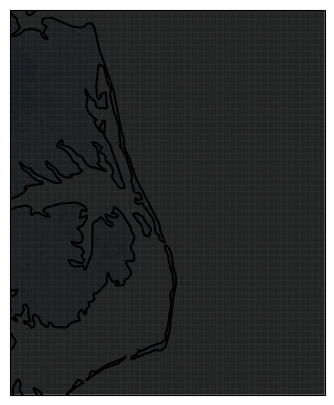

In [2]:
from utils.plotting import plot_selected_bathy

plot_selected_bathy(bathy=bathy)

In [3]:
from bluemath_tk.topo_bathy.swan_grid import generate_grid_parameters

fixed_parameters = generate_grid_parameters(bathy_data=bathy)
fixed_parameters

{'xpc': 363166,
 'ypc': 3873132,
 'alpc': 0,
 'xlenc': 182000,
 'ylenc': 222500,
 'mxc': 364,
 'myc': 445,
 'xpinp': np.float64(363166.25071576727),
 'ypinp': np.float64(3873132.821336043),
 'alpinp': 0,
 'mxinp': 364,
 'myinp': 445,
 'dxinp': np.float64(500.0),
 'dyinp': np.float64(500.0)}

## Create SWAN cases

In [4]:
from bluemath_tk.waves.binwaves import generate_swan_cases
from utils.wrapper import example_directions, example_frequencies

# Generate swan model parameters
example_directions = example_directions
swan_cases_df = (
    generate_swan_cases(
        directions_array=example_directions,
        frequencies_array=example_frequencies,
    )
    .astype(float)
    .to_dataframe()
    .reset_index()
)
swan_cases_df

,dir,freq,hs,tp,spr,gamma
0,7.5,0.035000,1.0,28.5714,2.0,50.0
1,7.5,0.038500,1.0,25.9740,2.0,50.0
2,7.5,0.042350,1.0,23.6128,2.0,50.0
3,7.5,0.046585,1.0,21.4661,2.0,50.0
4,7.5,0.051243,1.0,19.5147,2.0,50.0
...,...,...,...,...,...,...
691,352.5,0.344741,0.1,2.9007,2.0,50.0
692,352.5,0.379215,0.1,2.6370,2.0,50.0
693,352.5,0.417136,0.1,2.3973,2.0,50.0
694,352.5,0.458850,0.1,2.1794,2.0,50.0


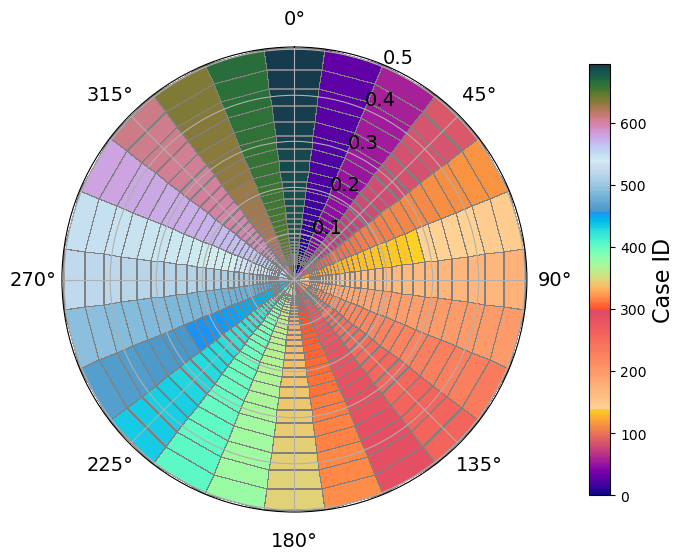

In [5]:
import numpy as np
from bluemath_tk.waves.binwaves import plot_selected_cases_grid

# Plot the cases grid

plot_selected_cases_grid(
    frequencies=np.array(example_frequencies),
    directions=np.array(example_directions),
    figsize=(8, 8),
)

## Build and run SWAN cases

In [6]:
import os
from utils.wrapper import BinWavesWrapper

# Define the input templates and output directory for the wrapper

templates_dir = os.path.join(os.getcwd(), "templates")
templates_name = ["INPUT"]
output_dir = os.path.join(os.getcwd(), "NC_cases")

# Create an instance of the SWAN model wrapper

swan_wrapper = BinWavesWrapper(
    templates_dir=templates_dir,
    templates_name=templates_name,
    metamodel_parameters=swan_cases_df.to_dict(orient="list"),
    fixed_parameters=fixed_parameters,
    output_dir=output_dir,
    depth_dataarray=bathy,
)

Dataset coordinates: Coordinates:
  * lon      (lon) float64 3kB 3.632e+05 3.637e+05 ... 5.447e+05 5.452e+05
  * lat      (lat) float64 4kB 3.873e+06 3.874e+06 ... 4.095e+06 4.096e+06
Dataset dimensions: ('lat', 'lon')
Dataset variables: No variables


2025-05-13 10:43:11,778 - BinWavesWrapper - WARNING - Parameter dir is not in the default_parameters
2025-05-13 10:43:11,779 - BinWavesWrapper - WARNING - Parameter freq is not in the default_parameters
2025-05-13 10:43:11,779 - BinWavesWrapper - WARNING - Parameter hs is not in the default_parameters
2025-05-13 10:43:11,779 - BinWavesWrapper - WARNING - Parameter tp is not in the default_parameters
2025-05-13 10:43:11,780 - BinWavesWrapper - WARNING - Parameter spr is not in the default_parameters
2025-05-13 10:43:11,780 - BinWavesWrapper - WARNING - Parameter gamma is not in the default_parameters


In [7]:
swan_wrapper.locations

array([[ 454666.25071577, 3873632.82133604],
       [ 504666.25071577, 3873632.82133604],
       [ 454666.25071577, 3923632.82133604],
       [ 504666.25071577, 3923632.82133604],
       [ 454666.25071577, 3973632.82133604],
       [ 504666.25071577, 3973632.82133604],
       [ 454666.25071577, 4023632.82133604],
       [ 504666.25071577, 4023632.82133604],
       [ 454666.25071577, 4073632.82133604],
       [ 504666.25071577, 4073632.82133604],
       [ 514397.61      , 4051843.74      ]])

In [8]:
# Build the input files

swan_wrapper.build_cases(mode="one_by_one")
swan_cases_df.to_csv(os.path.join(output_dir, "swan_cases.csv"), index=False)

# Set the cases directories from the output directory
# Execute if the cases are already built

# swan_wrapper.set_cases_dirs_from_output_dir()

In [9]:
# Run the model

swan_wrapper.run_cases_in_background(launcher="/software/geocean/swan/swan_serial.exe", num_workers=10)

In [39]:
# Monitor running cases

swan_wrapper.monitor_cases()

,Case,Percentage
0,0000,100 %
1,0001,100 %
2,0002,100 %
3,0003,100 %
4,0004,100 %
...,...,...
691,0691,0 %
692,0692,0 %
693,0693,0 %
694,0694,0 %


In [40]:
# Post-process the output files

cases_bulk_parameters = swan_wrapper.postprocess_cases()
cases_bulk_parameters

2025-05-13 12:17:41,074 - BinWavesWrapper - WARNING - Output postprocessed file already exists. Skipping postprocessing.


<xarray.Dataset> Size: 453MB
Dimensions:   (case_num: 232, Yp: 446, Xp: 365)
Coordinates:
  * Xp        (Xp) float32 1kB 3.632e+05 3.637e+05 ... 5.447e+05 5.452e+05
  * Yp        (Yp) float32 2kB 3.873e+06 3.874e+06 ... 4.095e+06 4.096e+06
  * case_num  (case_num) int64 2kB 0 1 2 3 4 5 6 ... 225 226 227 228 229 230 231
Data variables:
    Hsig      (case_num, Yp, Xp) float32 151MB ...
    Tm02      (case_num, Yp, Xp) float32 151MB ...
    Dir       (case_num, Yp, Xp) float32 151MB ...

/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/bluemath_tk/core/operations.py:342: RuntimeWarning: invalid value encountered in multiply
  x_rad = x_deg * np.pi / 180
/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/matplotlib/colors.py:2293: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin


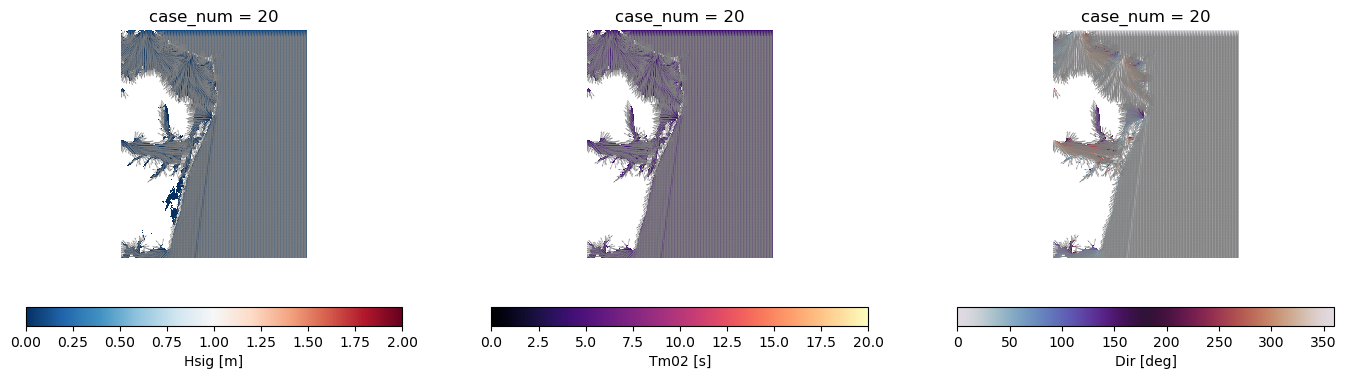

In [35]:
from utils.plotting import plot_case_variables

plot_case_variables(
    data=cases_bulk_parameters.isel(case_num=20),
)

## Plot ALL pre-run cases

"not all values found in index 'case_num'. Try setting the `method` keyword argument (example: method='nearest')."
"not all values found in index 'case_num'. Try setting the `method` keyword argument (example: method='nearest')."
"not all values found in index 'case_num'. Try setting the `method` keyword argument (example: method='nearest')."
"not all values found in index 'case_num'. Try setting the `method` keyword argument (example: method='nearest')."
"not all values found in index 'case_num'. Try setting the `method` keyword argument (example: method='nearest')."
"not all values found in index 'case_num'. Try setting the `method` keyword argument (example: method='nearest')."
"not all values found in index 'case_num'. Try setting the `method` keyword argument (example: method='nearest')."
"not all values found in index 'case_num'. Try setting the `method` keyword argument (example: method='nearest')."
"not all values found in index 'case_num'. Try setting the `method` keyword argu

/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/matplotlib/colors.py:2293: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin


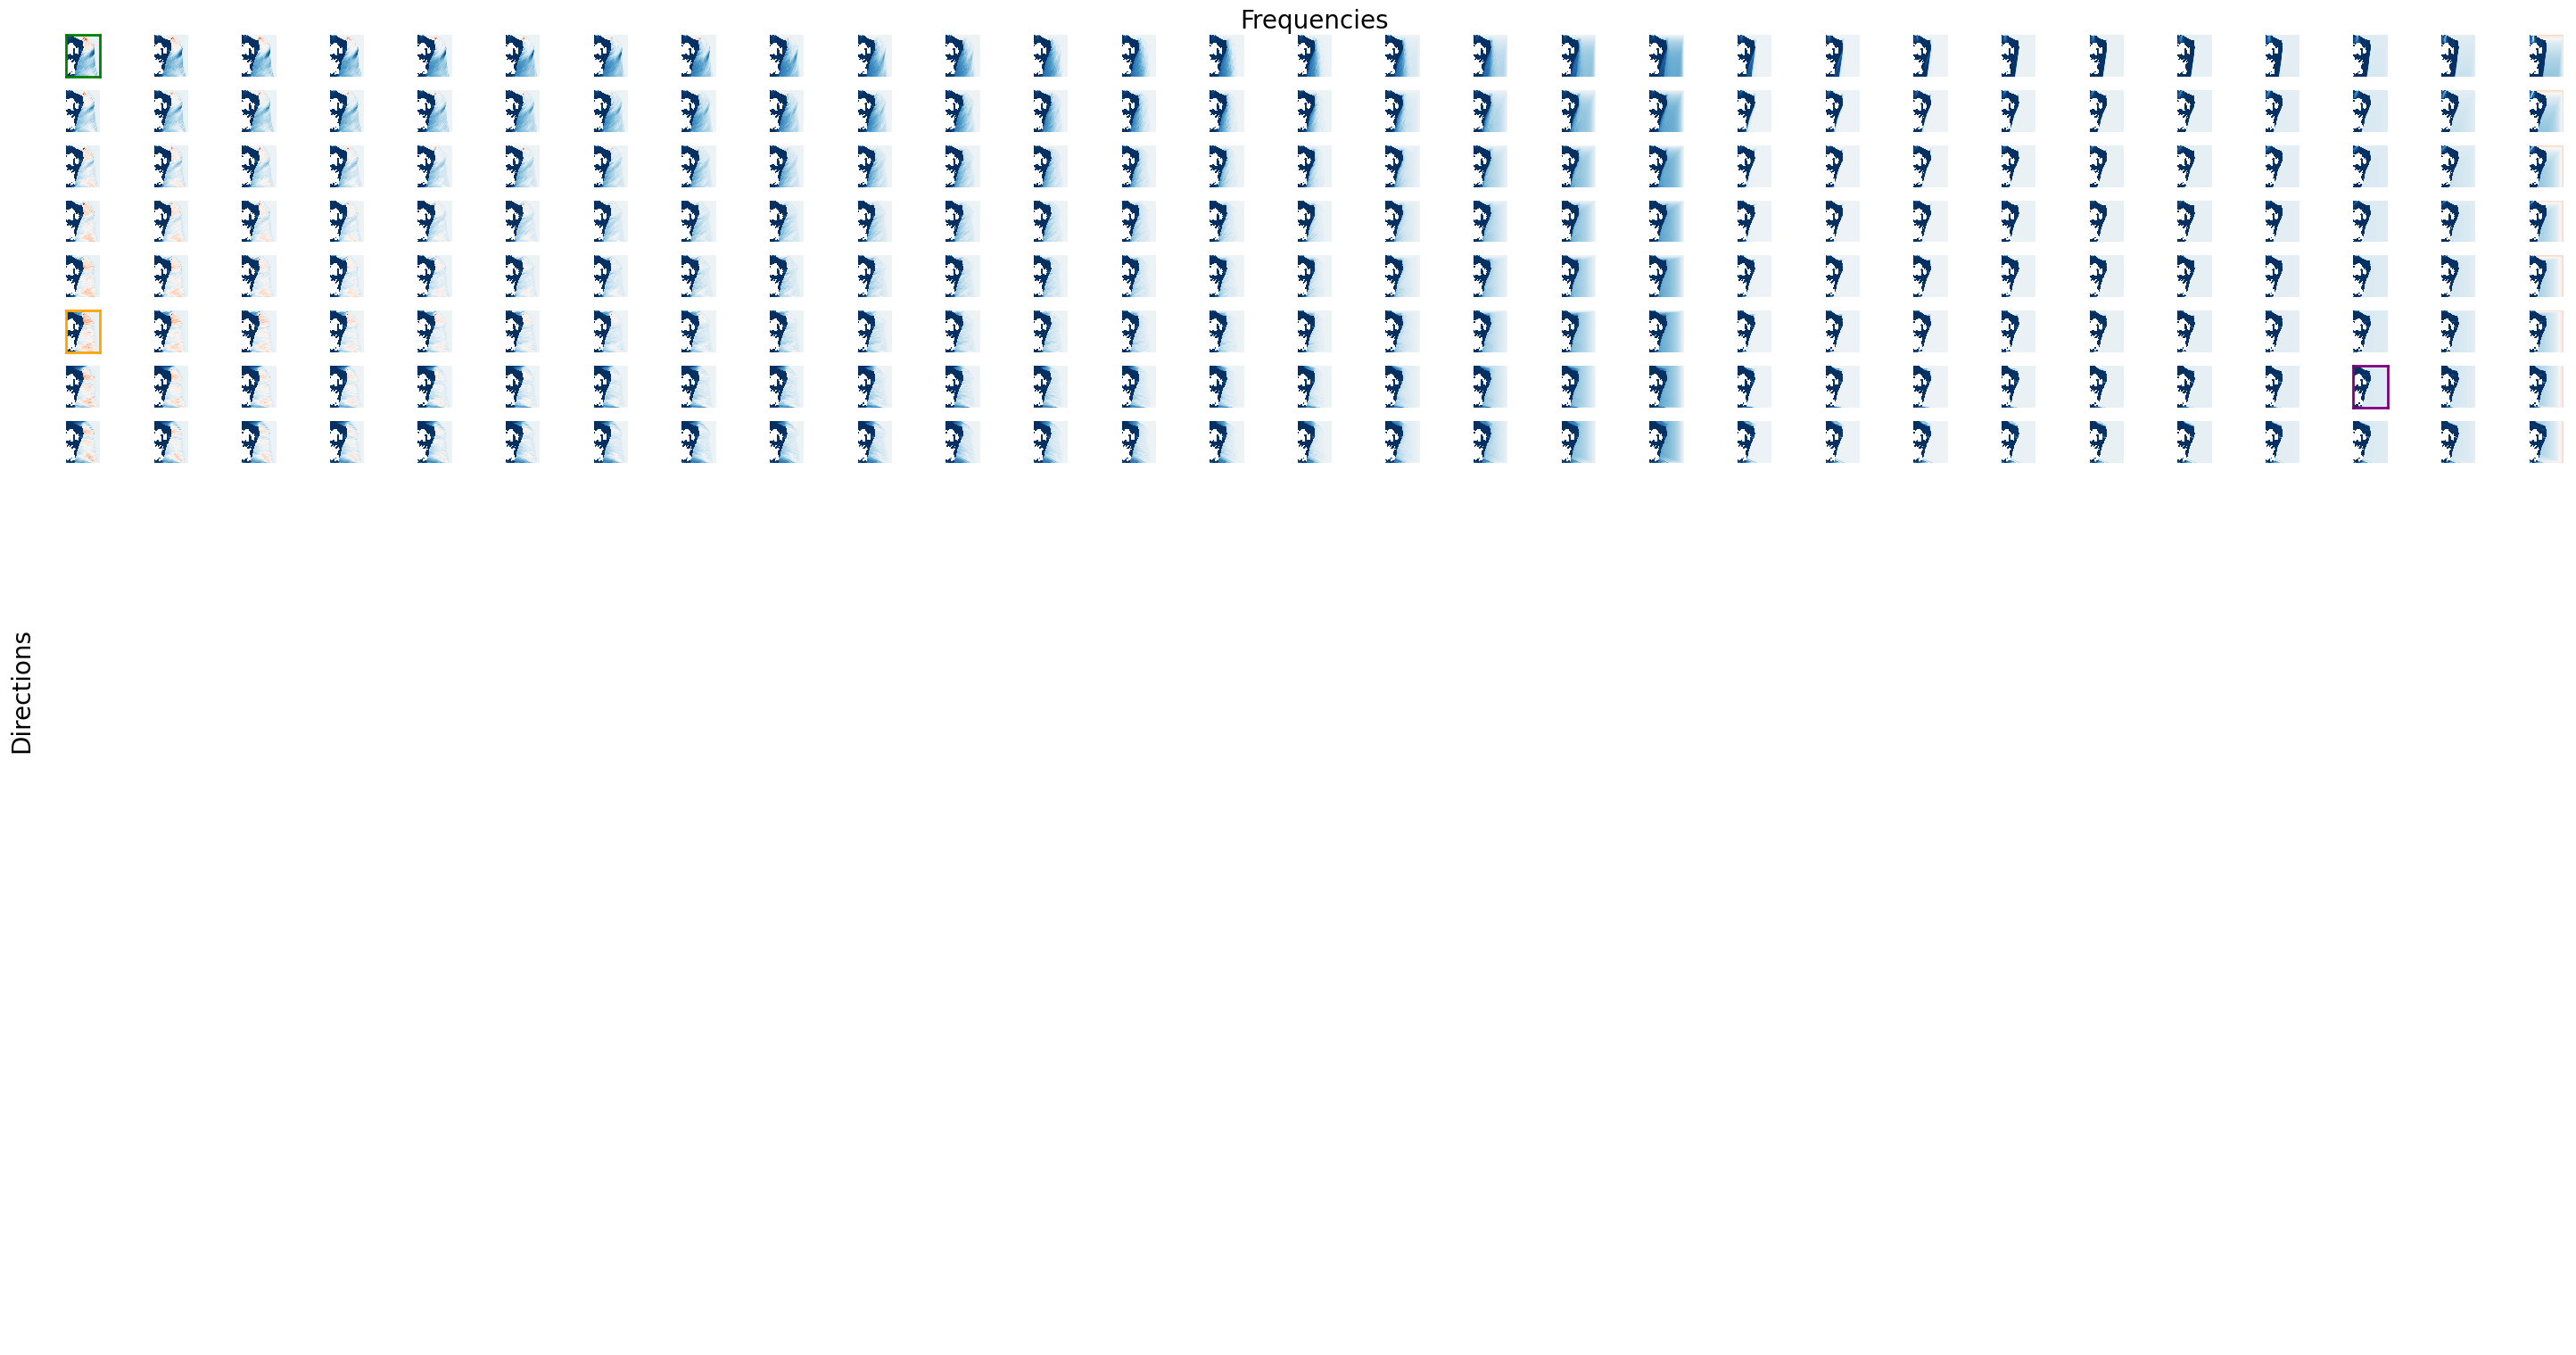

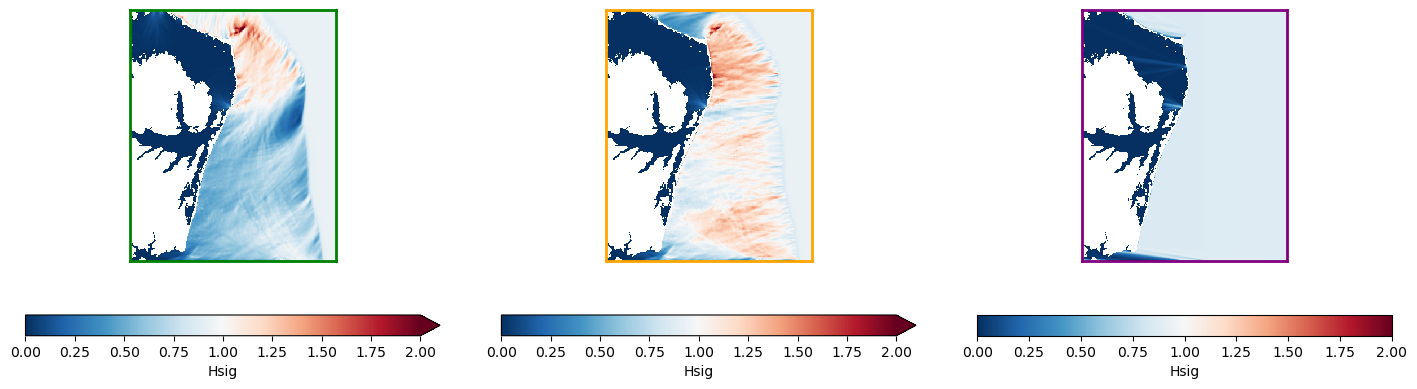

In [41]:
from utils.plotting import plot_cases_grid

plot_cases_grid(
    data=cases_bulk_parameters.Hsig.where(
        cases_bulk_parameters.case_num.isin(
            swan_cases_df.where(swan_cases_df["hs"] == 1.0).dropna().index.values
        ),
        cases_bulk_parameters.Hsig * 10,
    ),
    cases_to_plot=[0, 145, 200],
    num_directions=len(example_directions),
    num_frequencies=len(example_frequencies),
)

## Extract kp coefficients

In [13]:
# ps aux | grep python
# pkill -f "python"

In [37]:
from bluemath_tk.waves.binwaves import process_kp_coefficients

list_of_input_spectra = [
    os.path.join(case_dir, "input_spectra_N.bnd")
    for case_dir in swan_wrapper.cases_dirs
]
list_of_output_spectra = [
    os.path.join(case_dir, "output.spec") for case_dir in swan_wrapper.cases_dirs
]

kp_coefficients = process_kp_coefficients(
    list_of_input_spectra=list_of_input_spectra,
    list_of_output_spectra=list_of_output_spectra,
)
kp_coefficients

Error processing /lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/NC_cases/0324/input_spectra_N.bnd and /lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/NC_cases/0324/output.spec
[Errno 2] No such file or directory: '/lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/NC_cases/0324/output.spec'
Error processing /lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/NC_cases/0334/input_spectra_N.bnd and /lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/NC_cases/0334/output.spec
[Errno 2] No such file or directory: '/lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/NC_cases/0334/output.spec'
Error processing /lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/NC_cases/0335/input_spectra_N.bnd and /lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_dow

/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/wavespectra/core/swan.py:151: UserWarning: Check what this is supposed to be doing.
  warnings.warn("Check what this is supposed to be doing.")


Error processing /lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/NC_cases/0350/input_spectra_N.bnd and /lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/NC_cases/0350/output.spec
[Errno 2] No such file or directory: '/lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/NC_cases/0350/output.spec'
Error processing /lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/NC_cases/0351/input_spectra_N.bnd and /lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/NC_cases/0351/output.spec
[Errno 2] No such file or directory: '/lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/NC_cases/0351/output.spec'
Error processing /lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/NC_cases/0352/input_spectra_N.bnd and /lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_dow

<xarray.DataArray 'efth' (case_num: 333, site: 11, freq: 31, dir: 24)> Size: 22MB
array([[[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [8.73372592e-03, 2.28950159e-02, 4.07346435e-02, ...,
          2.66726005e-04, 8.43598526e-04, 2.20204027e-03],
         [1.28648775e-02, 3.34399975e-02, 5.84005891e-02, ...,
          3.84581681e-04, 1.21577435e-03, 3.20691499e-03],
         ...,
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

        [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [1.60561684e-03, 0.00000000e+00, 3.57322729e-02, ...,
          2.20893953e-03, 1.96566425e-03, 2.04351234e-03],
         [2.55925593e-03, 0.00000000e+00, 5.39973808e-02, ...,
          3.61020513e-03, 3.23069570e-03, 3.38639187e-03],
...
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

        [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         ...,
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00]]]],
      shape=(333, 11, 31, 24))
Coordinates:
  * case_num  (case_num) int64 3kB 0 1 2 3 4 5 6 ... 327 328 329 330 331 332 333
  * site      (site) int64 88B 1 2 3 4 5 6 7 8 9 10 11
  * freq      (freq) float64 248B 0.03 0.0329 0.0362 ... 0.4145 0.4552 0.5
  * dir       (dir) float64 192B 7.5 22.5 37.5 52.5 ... 307.5 322.5 337.5 352.5
    time      datetime64[ns] 8B 2025-05-13T11:53:00
    lat       float64 8B 0.0
    lon       float64 8B 0.0

In [42]:
# kp_coefficients.to_dataset(name="kps").drop(["time", "lat", "lon"]).assign_coords(
#     utm_x=(("site"), swan_wrapper.locations[:, 0]),
#     utm_y=(("site"), swan_wrapper.locations[:, 1]),
# ).to_netcdf("outputs/kp_coefficients.nc")
# If you only need to drop 'time':
kp_coefficients.to_dataset(name="kps").drop(["time"]).assign_coords(
    utm_x=(("site"), swan_wrapper.locations[:, 0]),
    utm_y=(("site"), swan_wrapper.locations[:, 1]),
).to_netcdf("outputs/kp_coefficients.nc")

/tmp/ipykernel_2655054/4113431545.py:6: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  kp_coefficients.to_dataset(name="kps").drop(["time"]).assign_coords(
